In [1]:
## Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

PROCESSED = Path("../data/processed")
MODELS = Path("../models")
MODELS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

## Load & feature engineering

In [2]:
daily_sales = pd.read_csv(PROCESSED / "daily_sales.csv", parse_dates=["date"])
daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

df = daily_sales[["date", "total_revenue"]].copy()

# Fitur waktu
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Senin
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Lag features
df["lag_1"] = df["total_revenue"].shift(1)
df["lag_7"] = df["total_revenue"].shift(7)

# Rolling features (pakai shift(1) dulu supaya tidak bocor data hari itu sendiri)
df["rolling_mean_7"] = df["total_revenue"].shift(1).rolling(7).mean()
df["rolling_mean_14"] = df["total_revenue"].shift(1).rolling(14).mean()

df_model = df.dropna().reset_index(drop=True)
print(f"Total baris setelah feature engineering: {len(df_model)} (dari {len(df)} awal)")
df_model.head()

Total baris setelah feature engineering: 106 (dari 120 awal)


,date,total_revenue,day_of_week,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_14
0,2026-06-12,1060000.0,4,0,570000.0,1019500.0,643357.142857,681178.571429
1,2026-06-13,1105500.0,5,1,1060000.0,1366000.0,649142.857143,678142.857143
2,2026-06-14,1860500.0,6,1,1105500.0,584500.0,611928.571429,738178.571429
3,2026-06-15,702000.0,0,0,1860500.0,395000.0,794214.285714,812500.000000
4,2026-06-16,625000.0,1,0,702000.0,276500.0,838071.428571,803000.000000


## Train/test split — time-based, BUKAN random

In [3]:
# 80/20 berdasarkan urutan waktu
split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

feature_cols = ["day_of_week", "is_weekend", "lag_1", "lag_7", "rolling_mean_7", "rolling_mean_14"]
target_col = "total_revenue"

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train: {len(train)} hari ({train['date'].min().date()} - {train['date'].max().date()})")
print(f"Test : {len(test)} hari ({test['date'].min().date()} - {test['date'].max().date()})")

Train: 84 hari (2026-06-12 - 2026-09-03)
Test : 22 hari (2026-09-04 - 2026-09-25)


## Modeling

In [4]:
## Evaluasi helper
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:20s} | MAE: Rp{mae:>12,.0f} | RMSE: Rp{rmse:>12,.0f} | MAPE: {mape:5.1f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []

### Baseline

In [5]:
## Baseline 1: Naive (prediksi = nilai kemarin)
naive_pred = X_test["lag_1"].values
results.append(evaluate(y_test.values, naive_pred, "Naive (lag_1)"))

Naive (lag_1)        | MAE: Rp     447,750 | RMSE: Rp     532,428 | MAPE:  52.8%


In [6]:
## Baseline 2: Moving Average (prediksi = rolling mean 7 hari)
ma_pred = X_test["rolling_mean_7"].values
results.append(evaluate(y_test.values, ma_pred, "Moving Average (7d)"))

Moving Average (7d)  | MAE: Rp     304,153 | RMSE: Rp     383,901 | MAPE:  36.3%


### Random Forest

In [7]:
## Model 3: Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(evaluate(y_test.values, rf_pred, "Random Forest"))

Random Forest        | MAE: Rp     247,366 | RMSE: Rp     362,844 | MAPE:  26.9%


### XGBoost

In [8]:
## Model 4: XGBoost
xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(evaluate(y_test.values, xgb_pred, "XGBoost"))

XGBoost              | MAE: Rp     341,893 | RMSE: Rp     432,023 | MAPE:  35.9%


## Evaluasi Model

              model           MAE          RMSE      MAPE
      Random Forest 247365.848800 362844.112046 26.940345
Moving Average (7d) 304152.597403 383901.100497 36.253957
            XGBoost 341892.505682 432023.005533 35.924590
      Naive (lag_1) 447750.000000 532428.238869 52.832113


C:\Users\Tigro\AppData\Local\Temp\ipykernel_28044\21750521.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="MAE", y="model", ax=ax, palette="viridis")


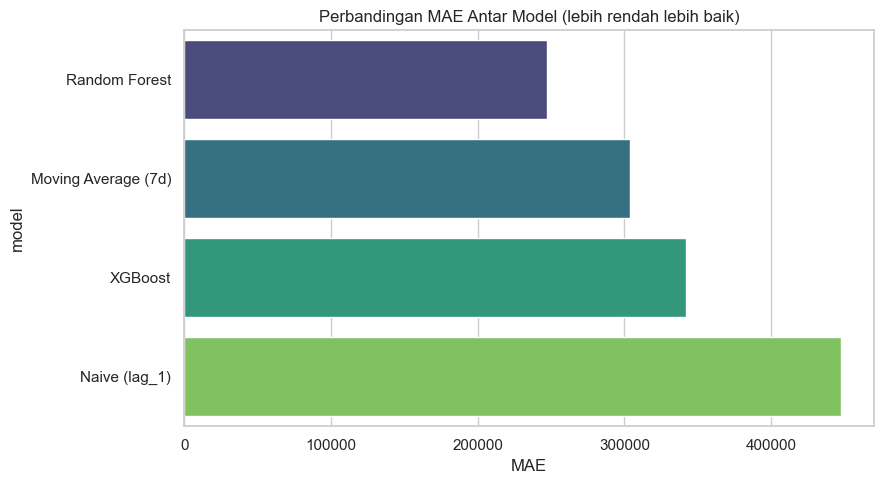

In [9]:
## Bandingkan semua model
results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=results_df, x="MAE", y="model", ax=ax, palette="viridis")
ax.set_title("Perbandingan MAE Antar Model (lebih rendah lebih baik)")
plt.tight_layout()
plt.show()

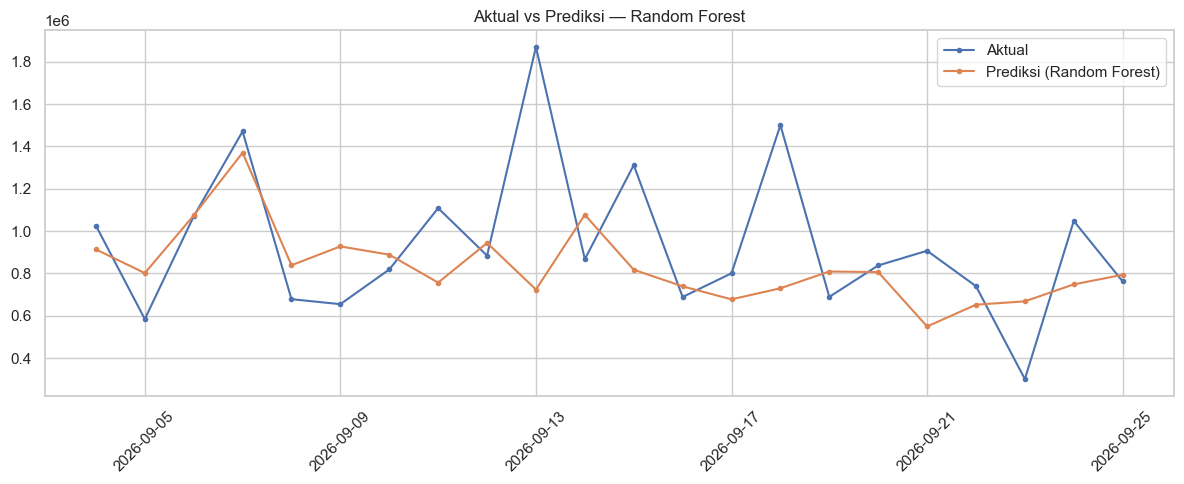

In [10]:
## Visualisasi prediksi terbaik vs aktual
best_model_name = results_df.iloc[0]["model"]
pred_map = {
    "Naive (lag_1)": naive_pred,
    "Moving Average (7d)": ma_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
}
best_pred = pred_map[best_model_name]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["date"], y_test.values, label="Aktual", marker="o", markersize=3)
ax.plot(test["date"], best_pred, label=f"Prediksi ({best_model_name})", marker="o", markersize=3)
ax.set_title(f"Aktual vs Prediksi — {best_model_name}")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance

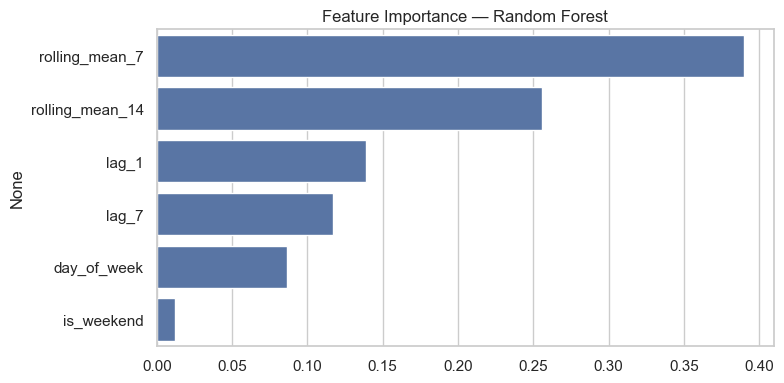

rolling_mean_7     0.390162
rolling_mean_14    0.255500
lag_1              0.138821
lag_7              0.117114
day_of_week        0.086545
is_weekend         0.011859
dtype: float64


In [12]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, ax=ax)
ax.set_title(f"Feature Importance — {best_model_name}")
plt.tight_layout()
plt.show()
print(importances)

## Simpan model terbaik

In [13]:
model_map = {"Random Forest": rf, "XGBoost": xgb}

if best_model_name in model_map:
    best_model = model_map[best_model_name]
    joblib.dump({
        "model": best_model,
        "feature_cols": feature_cols,
        "model_name": best_model_name,
    }, MODELS / "sales_forecast.pkl")
    print(f"Model '{best_model_name}' tersimpan ke models/sales_forecast.pkl")
else:
    print(f"Baseline '{best_model_name}' menang — tidak ada model ML yang disimpan.")
    print("Ini valid untuk dilaporkan: baseline sederhana ternyata cukup kompetitif pada data ini.")

Model 'Random Forest' tersimpan ke models/sales_forecast.pkl
